# Retrieval Semantics

Run `python retrieval_semantics.py --model-name <model>` from this folder to compute the `.npz` results, then use the cells below to load and plot them.

In [1]:
import os
import sys
from pathlib import Path

os.environ["JAX_PLATFORMS"] = "cpu"

RETRIEVAL_DIR = Path.cwd().resolve()
REPO_ROOT = RETRIEVAL_DIR.parent
LOCAL_RESULTS_ROOT = RETRIEVAL_DIR / 'results'
LEGACY_RESULTS_ROOT = REPO_ROOT / 'results'
LOCAL_RESULTS_RECALL_SEM = str(LOCAL_RESULTS_ROOT / 'recall' / 'sem') + '/'
LEGACY_RESULTS_RECALL_SEM = str(LEGACY_RESULTS_ROOT / 'recall' / 'sem') + '/'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import makefolder, depths
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

rcpsize = 20
plt.rcParams['xtick.labelsize'] = rcpsize
plt.rcParams['ytick.labelsize'] = rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
markers = ['p', 'o', 'h', '^', 's', '*']
_linestyles = ['-', '--', 'dotted']
plot_id = 0


/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_name = 'gemma12b'
precision = 32
data_var = 'sem'
global_center_flag = 1
min_token_length = 3
n_tokens = min_token_length
k_recall = 3
avg_tokens = 1

resultsfolder = makefolder(
    base=LOCAL_RESULTS_RECALL_SEM,
    model_name=model_name,
    avg_tokens=avg_tokens,
    min_token_length=min_token_length,
    global_center_flag=global_center_flag,
    k=k_recall,
)
results_path = os.path.join(resultsfolder, f'recall_k{k_recall}.npz')

if not os.path.exists(results_path):
    resultsfolder = makefolder(
        base=LEGACY_RESULTS_RECALL_SEM,
        model_name=model_name,
        avg_tokens=avg_tokens,
        min_token_length=min_token_length,
        global_center_flag=global_center_flag,
        k=k_recall,
    )
    results_path = os.path.join(resultsfolder, f'recall_k{k_recall}.npz')

data = np.load(results_path)

layer_vals = data['layer_vals']
rel_depths = data['rel_depths']
recalls_0 = data['recalls_0']
recalls_sem = data['recalls_sem']
recalls_syn = data['recalls_syn']
recalls_sem_perm = data['recalls_sem_perm']
recalls_syn_perm = data['recalls_syn_perm']


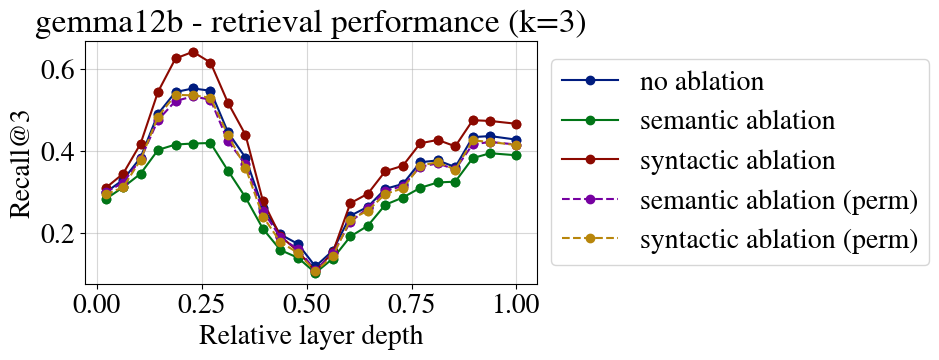

In [3]:
layer_vals_arr = np.array(layer_vals)
rel_depths = layer_vals_arr / depths[model_name]

fig, ax = plt.subplots(figsize=(7, 4))

plt.plot(rel_depths, recalls_0, marker='o', label='no ablation')
plt.plot(rel_depths, recalls_sem, marker='o', label='semantic ablation')
plt.plot(rel_depths, recalls_syn, marker='o', label='syntactic ablation')
plt.plot(
    rel_depths,
    recalls_sem_perm,
    marker='o',
    linestyle='--',
    label='semantic ablation (perm)',
)
plt.plot(
    rel_depths,
    recalls_syn_perm,
    marker='o',
    linestyle='--',
    label='syntactic ablation (perm)',
)

plt.scatter(rel_depths, recalls_0, alpha=0.9)
plt.scatter(rel_depths, recalls_sem, alpha=0.9)
plt.scatter(rel_depths, recalls_syn, alpha=0.9)
plt.scatter(rel_depths, recalls_sem_perm, alpha=0.9)
plt.scatter(rel_depths, recalls_syn_perm, alpha=0.9)

plt.xlabel('Relative layer depth')
plt.ylabel(f'Recall@{k_recall}')
plt.title(f'{model_name} - retrieval performance (k={k_recall})')
plt.grid(True, alpha=0.5)
plt.tight_layout()

box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig_path = os.path.join(resultsfolder, f'recall_k{k_recall}.png')
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()
